# EDA - Holidays

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.data import load_data

df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ],
    'politics': [
        'the_donald', 'politic', 'conspiracy', 'conservative', 'worldpolitics', 'libertarian', 'mensrights', 'new_right', 'theredpill', 'anarcho_capitalism', 'whiterights', 'european', 'politicalvideo', 'metacanada', 'hillaryforprison', 'uncensorednews', 'asktrumpsupporters', 'altnewz', 'kossacks_for_sanders', 'wayofthebern', 'republican', 'conservatives'
    ],
    'gaming' : [
        'gaming', 'pcmasterrace', 'ps4', 'xboxone', 'games', 'rainbow6', 'minecraft', 'fo4', 'darksouls3', 'thedivision', 'fallout', 'dayz', 'halo', 'darksouls2', 'skyrim', 'grandtheftautov', 'oculus', 'witcher', 'kerbalspaceprogram', 'battlefield_one', 'battlefield_4', 'globaloffensivetrade', 'fireteams', 'rocketleagueexchange', 'dota2', 'leagueoflegends', 'globaloffensive', 'destinythegame', 'overwatch', 'hearthstone', 'wow', '2007scape', 'pokemongo', 'smite', 'runescape'
    ]
}

# Dictionary to hold merged dataframes
merged_dfs = {}

# Merge with the neighbors found (centroid)
for theme_name, initial_subs in THEMES.items():
    neighbors_centroid_path = f'../data/{theme_name}_centroid_neighbors.csv'

    if os.path.exists(neighbors_centroid_path):
        neighbors_df = pd.read_csv(neighbors_centroid_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_centroid'] = merged_df
    else:
        print(f'File not found :( ')

    # Do the same for max similarity neighbors

    neighbors_maxsim_path = f'../data/{theme_name}_max_similarity_neighbors.csv'

    if os.path.exists(neighbors_maxsim_path):
        neighbors_df = pd.read_csv(neighbors_maxsim_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_maxsim'] = merged_df
    else:
        print(f'File not found :( ')

# Dataframes
sports_centroid_df = merged_dfs.get('sports_centroid')
politics_centroid_df = merged_dfs.get('politics_centroid')
gaming_centroid_df = merged_dfs.get('gaming_centroid')
sports_maxsim_df = merged_dfs.get('sports_maxsim')
politics_maxsim_df = merged_dfs.get('politics_maxsim')
gaming_maxsim_df = merged_dfs.get('gaming_maxsim')

In [11]:
df_subreddits['SUBREDDIT']

0                     spiders
1                   askreddit
2        globaloffensivetrade
3                   fireteams
4                       funny
                 ...         
51273                    33rd
51274           bestofvic2015
51275             aberystwyth
51276         mail_forwarding
51277                   cover
Name: SUBREDDIT, Length: 51278, dtype: object

In [12]:
df_body

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."
...,...,...,...,...,...,...
286556,negareddit,debatefascism,68im20s,2017-04-30 16:31:26,1,"441.0,405.0,0.775510204082,0.0294784580499,0.0..."
286557,mildlynomil,justnomil,68imlas,2017-04-30 04:19:03,1,"2226.0,1855.0,0.786163522013,0.00224618149146,..."
286558,mmorpg,blackdesertonline,68ip5os,2017-04-30 16:54:08,1,"1100.0,909.0,0.778181818182,0.00181818181818,0..."
286559,electricskateboards,askreddit,68ipb2s,2017-04-30 16:41:53,1,"1876.0,1567.0,0.78144989339,0.00692963752665,0..."


# Familiarize yourself with df_holydays

In [13]:
df_holidays

,ADM_name,ISO3,Date,Name,Type
44,Aruba,ABW,2014-01-01,New Year's Day,Public holiday
45,Aruba,ABW,2014-01-25,Betico Croes' Birthday,Public holiday
46,Aruba,ABW,2014-03-03,Carnival Monday,Public holiday
47,Aruba,ABW,2014-03-18,National Anthem and Flag Day,Public holiday
48,Aruba,ABW,2014-04-18,Good Friday,Public holiday
...,...,...,...,...,...
44379,Palestine,PSE,2017-04-25,Prophet's Ascension,Public holiday
44386,Palestine,PSE,2014-01-13,Prophet's Birthday,Public holiday
44387,Palestine,PSE,2015-01-03,Prophet's Birthday,Public holiday
44388,Palestine,PSE,2015-12-24,Prophet's Birthday,Public holiday


In [14]:
for col in df_holidays.columns:
    print(f"Column: {col}")
    value_counts = df_holidays[col].value_counts()
    print(f"Unique values: {value_counts.shape[0]}")
    print(value_counts)
    print("-" * 40)

Column: ADM_name
Unique values: 232
ADM_name
Us                       361
India                    211
Spain                    200
Canada                   194
China                    178
                        ... 
Guinea-bissau             30
Mauritania                26
Sao-tome-and-principe     23
Uruguay                   17
Mayotte                   14
Name: count, Length: 232, dtype: int64
----------------------------------------
Column: ISO3
Unique values: 232
ISO3
USA    361
IND    211
ESP    200
CAN    194
CHN    178
      ... 
GNB     30
MRT     26
STP     23
URY     17
MYT     14
Name: count, Length: 232, dtype: int64
----------------------------------------
Column: Date
Unique values: 1193
Date
2016-05-01    195
2015-12-25    193
2014-12-25    191
2016-12-25    191
2015-05-01    175
             ... 
2016-06-15      1
2015-02-26      1
2014-02-26      1
2016-05-13      1
2016-12-22      1
Name: count, Length: 1193, dtype: int64
----------------------------------------
C

In [15]:
missing_values = df_holidays.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")

Total missing values: 0


### 1. Date Analysis

In [16]:
df_holidays['Year'] = df_holidays['Date'].dt.year
df_holidays['Month'] = df_holidays['Date'].dt.month
df_holidays['Day'] = df_holidays['Date'].dt.day
df_holidays['DayOfWeek'] = df_holidays['Date'].dt.dayofweek
df_holidays['DayOfWeekName'] = df_holidays['Date'].dt.day_name()
df_holidays['MonthName'] = df_holidays['Date'].dt.month_name()

# check 
print(f"Date Range: {df_holidays['Date'].min()} to {df_holidays['Date'].max()}")
print(f"Time Span: {(df_holidays['Date'].max() - df_holidays['Date'].min()).days} days")

Date Range: 2014-01-01 00:00:00 to 2017-04-30 00:00:00
Time Span: 1215 days


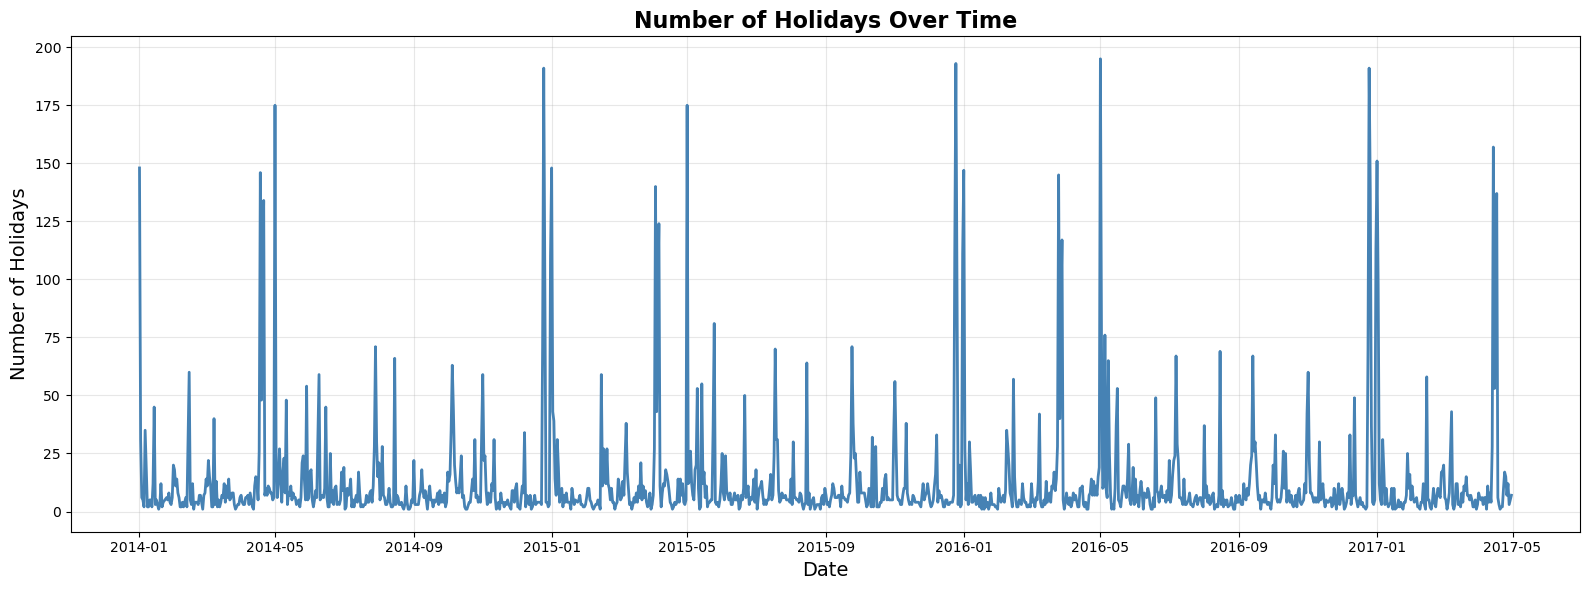

In [17]:
holidays_per_day = df_holidays.groupby('Date').size()

plt.figure(figsize=(16, 6))
plt.plot(holidays_per_day.index, holidays_per_day.values, color='steelblue', linewidth=2)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Holidays', fontsize=14)
plt.title('Number of Holidays Over Time', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

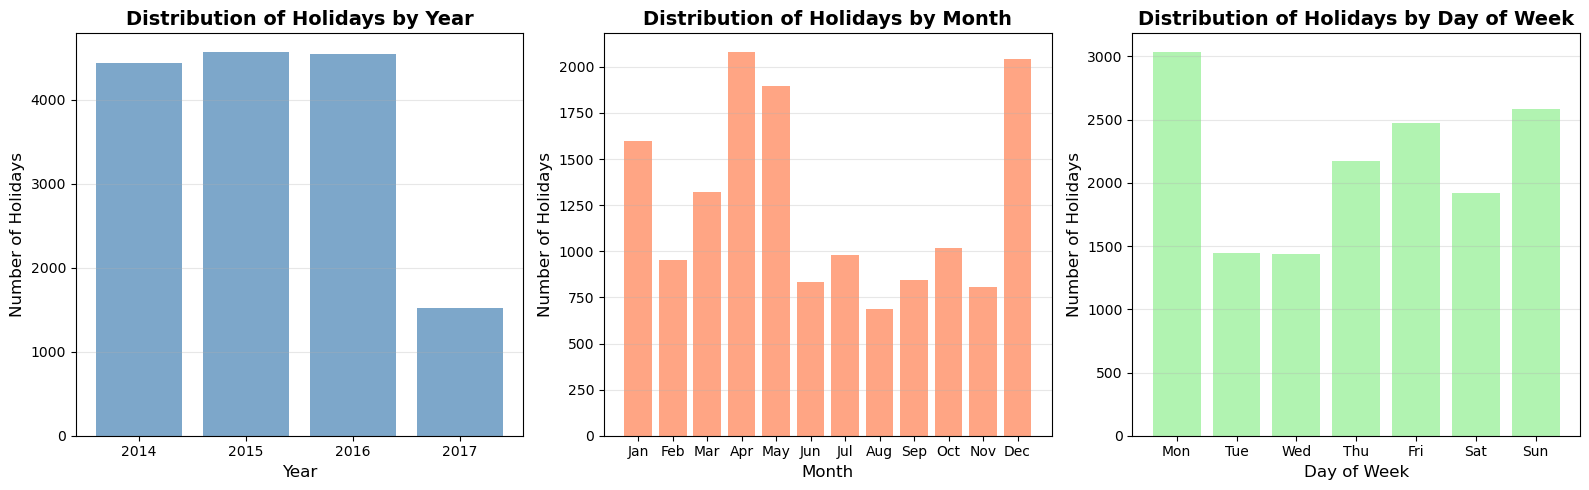

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Holidays distribution by year
year_counts = df_holidays['Year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Holidays', fontsize=12)
axes[0].set_title('Distribution of Holidays by Year', fontsize=14, fontweight='bold')
axes[0].set_xticks(year_counts.index)
axes[0].grid(axis='y', alpha=0.3)

# Holidays distribution by month
month_counts = df_holidays['Month'].value_counts().sort_index()
axes[1].bar(month_counts.index, month_counts.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Number of Holidays', fontsize=12)
axes[1].set_title('Distribution of Holidays by Month', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].grid(axis='y', alpha=0.3)

# Day of week distribution
dow_counts = df_holidays['DayOfWeekName'].value_counts()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.reindex(dow_order)
axes[2].bar(range(len(dow_counts)), dow_counts.values, color='lightgreen', alpha=0.7)
axes[2].set_xlabel('Day of Week', fontsize=12)
axes[2].set_ylabel('Number of Holidays', fontsize=12)
axes[2].set_title('Distribution of Holidays by Day of Week', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Country/Region Analysis

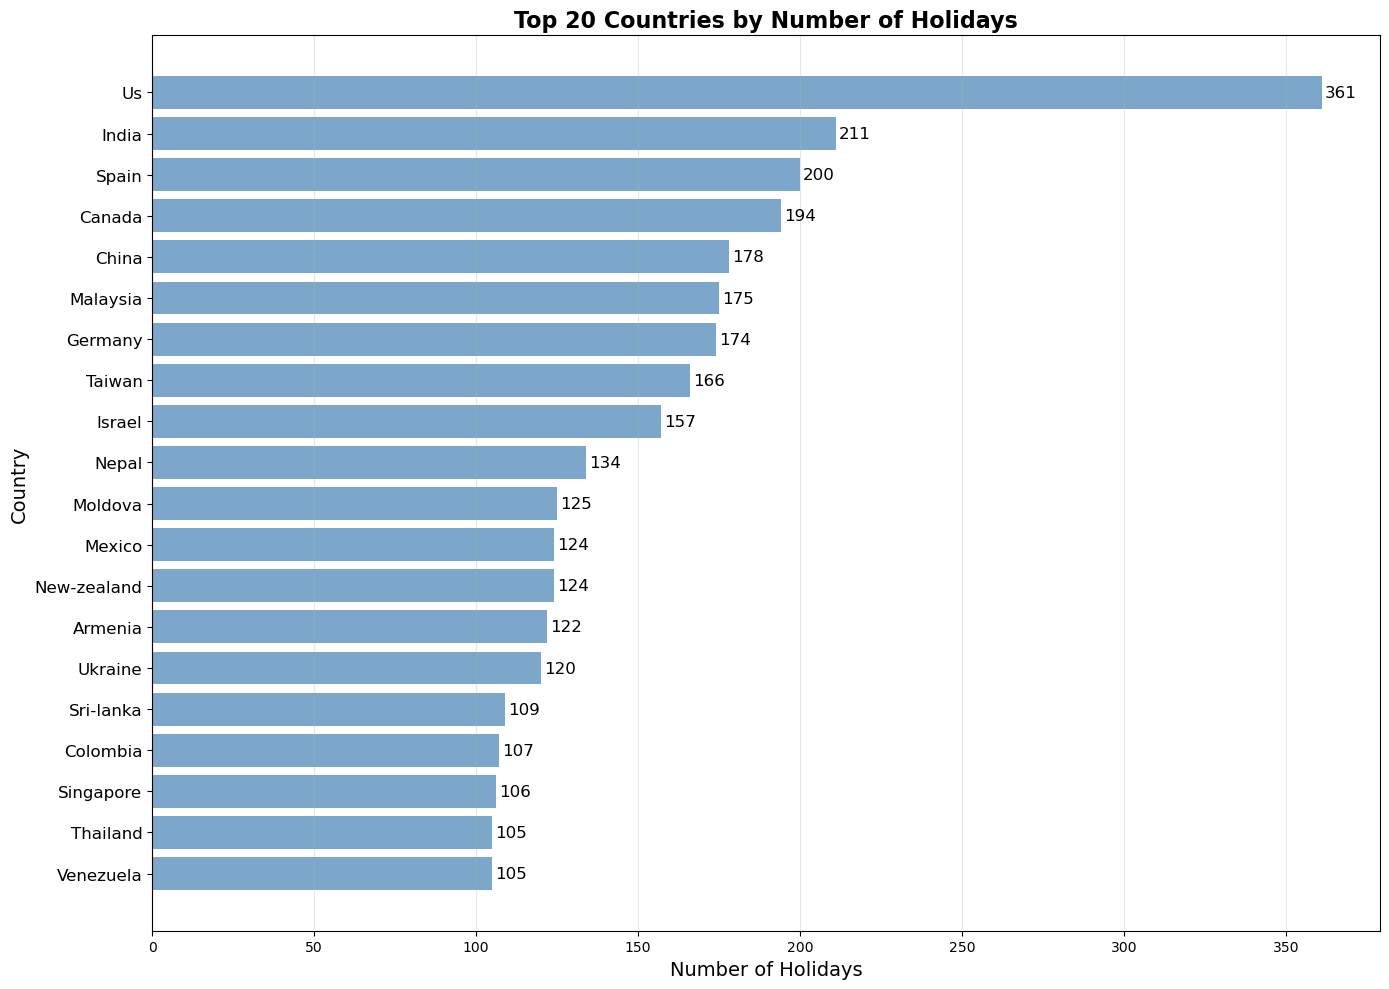

In [19]:
top_countries = df_holidays['ADM_name'].value_counts().head(20)

plt.figure(figsize=(14, 10))  # Reduced height for top 20, easier to read
bars = plt.barh(range(len(top_countries)), top_countries.values, color='steelblue', alpha=0.7)
plt.yticks(range(len(top_countries)), top_countries.index, fontsize=12)
plt.xlabel('Number of Holidays', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.title('Top 20 Countries by Number of Holidays', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{top_countries.values[i]}', va='center', fontsize=12)

plt.show()

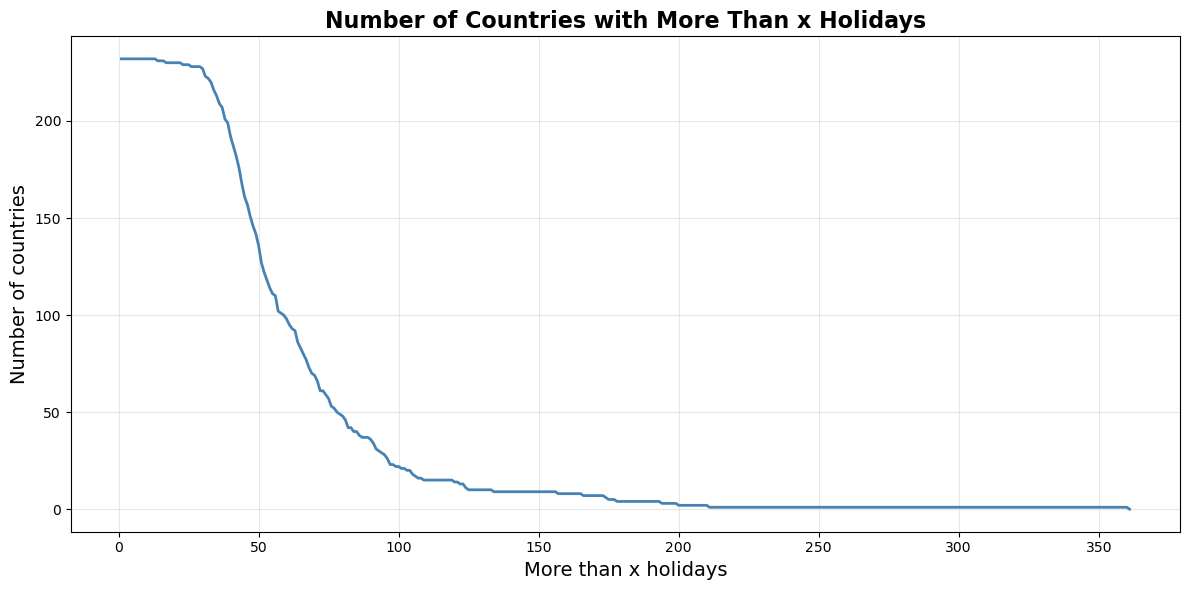

In [20]:
country_holiday_counts = df_holidays['ADM_name'].value_counts()
max_holidays = country_holiday_counts.max()

thresholds = range(1, max_holidays + 1)
countries_above_x = [sum(country_holiday_counts > x) for x in thresholds]

plt.figure(figsize=(12, 6))
plt.plot(thresholds, countries_above_x, color='steelblue', linewidth=2)
plt.xlabel('More than x holidays', fontsize=14)
plt.ylabel('Number of countries', fontsize=14)
plt.title('Number of Countries with More Than x Holidays', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Holiday Type Analysis

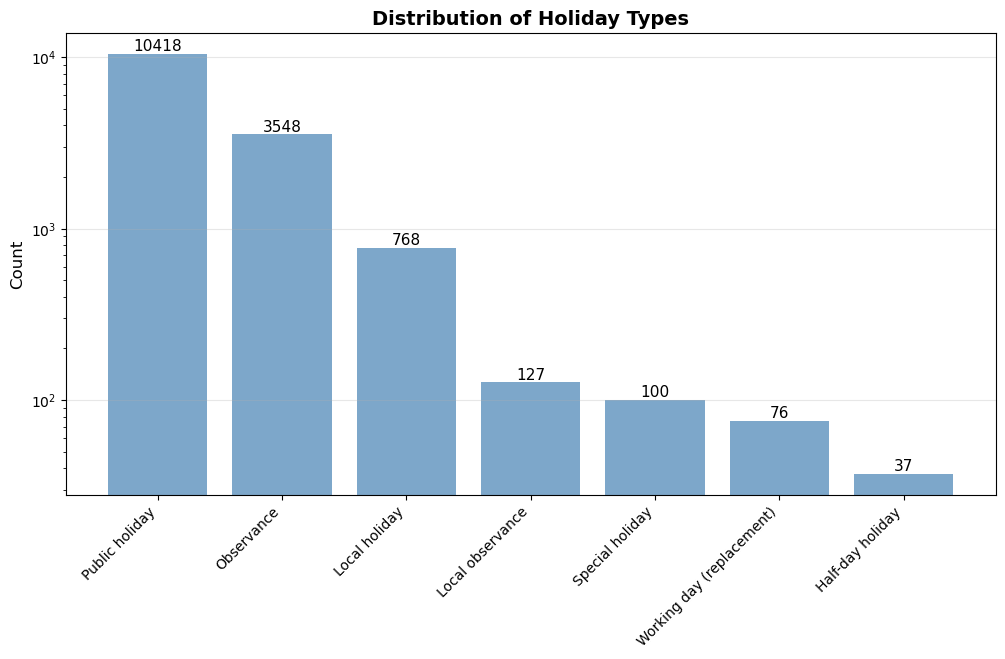

In [21]:
type_counts = df_holidays['Type'].value_counts()

plt.figure(figsize=(12, 6))

bars = plt.bar(range(len(type_counts)), type_counts.values, color='steelblue', alpha=0.7)
plt.xticks(range(len(type_counts)), type_counts.index, rotation=45, ha='right')
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Holiday Types', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')

# Add value labels to each bar
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{type_counts.values[i]}', ha='center', va='bottom', fontsize=11, color='black')

plt.show()

### 5. Holiday Names Analysis

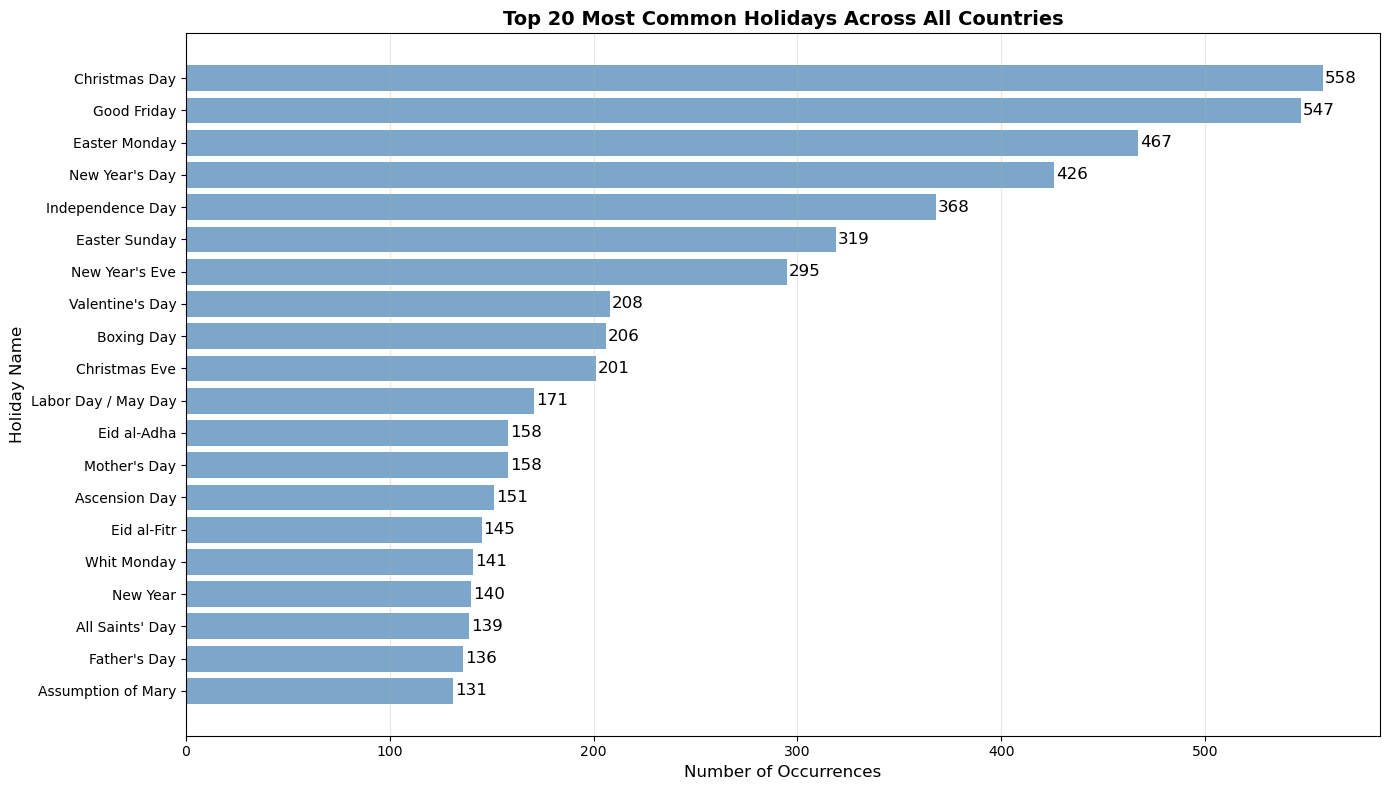

In [35]:
# Most common holidays across all countries
top_holidays = df_holidays['Name'].value_counts().head(20)

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(top_holidays)), top_holidays.values, color='steelblue', alpha=0.7)
plt.yticks(range(len(top_holidays)), top_holidays.index)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Holiday Name', fontsize=12)
plt.title('Top 20 Most Common Holidays Across All Countries', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Add value labels to each bar
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{top_holidays.values[i]}', va='center', fontsize=12)

plt.show()

---

# EDA - Holidays

check correlation with $df\_title$ and $df\_body$, use of $df\_subreddits$

In [ ]:
HOLIDAYS = [
    'christmas', 'christmaslights', 'thanksgiving', 'halloween', 'halloween_costumes', 'newyear', 'happynewyear', 'ramadan', 'valentinesday', 'valentine',  'mothersday', 'fathersday', 'independenceday', 'memorialday', 'eastereggs', 'blackfriday', 'diwali'
]

- How I came up with the list of subreddits HOLIDAYS:

In [33]:
for i in HOLIDAYS:
    exists = i in df_body['SOURCE_SUBREDDIT'].values
    print(f"Subreddit '{i}' exists: {exists}")

Subreddit 'christmas' exists: True
Subreddit 'christmaslights' exists: False
Subreddit 'thanksgiving' exists: True
Subreddit 'halloween' exists: True
Subreddit 'halloween_costumes' exists: True
Subreddit 'newyear' exists: False
Subreddit 'happynewyear' exists: False
Subreddit 'ramadan' exists: False
Subreddit 'valentinesday' exists: False
Subreddit 'valentine' exists: False
Subreddit 'mothersday' exists: False
Subreddit 'fathersday' exists: False
Subreddit 'independenceday' exists: False
Subreddit 'memorialday' exists: False
Subreddit 'eastereggs' exists: True
Subreddit 'blackfriday' exists: True
Subreddit 'diwali' exists: False


In [34]:
df_subreddits[df_subreddits['SUBREDDIT'].str.contains('international', case=False, na=False)]['SUBREDDIT'].tolist()

['internationalpolitics',
 'internationalnews',
 'internationalbusiness',
 'internationalbaseball',
 'bitcoininternational',
 'internationallaw',
 'internationaladoption',
 'internationaldev',
 'internationalwomen',
 'international_music',
 'internationalaffairs',
 'international',
 'internationalhockey',
 'internationaldgu',
 'internationalatheist']

In [35]:
df_subreddits[df_subreddits['SUBREDDIT'] == 'christmaslights']
#df_body[df_body['SOURCE_SUBREDDIT'] == 'christmaslights']

,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
48069,christmaslights,-0.005113,-0.059112,0.073888,-0.064459,0.011821,-0.034343,0.040418,0.000215,-0.082191,...,0.028997,0.008141,-0.006206,0.04298,0.016775,-0.034497,-0.04515,-0.005829,0.045073,0.00829


### WE SHOULD REMOVE THE ROWS IN df_subbreddit THAT NEVER (or don't appear enough) APPEAR IN  df_body AND df_title 

In [36]:
# Check how many times each holiday subreddit appears in SOURCE and TARGET
for subreddit in HOLIDAYS:
    body_source_count = (df_body['SOURCE_SUBREDDIT'] == subreddit).sum()
    body_target_count = (df_body['TARGET_SUBREDDIT'] == subreddit).sum()
    title_source_count = (df_title['SOURCE_SUBREDDIT'] == subreddit).sum()
    title_target_count = (df_title['TARGET_SUBREDDIT'] == subreddit).sum()

    print(f"{subreddit}:")
    print(f"As SOURCE: {body_source_count} (df_body), {title_source_count} (df_title)")
    print(f"As TARGET: {body_target_count} (df_body), {title_target_count} (df_title)")
    print("-" * 40)

christmas:
As SOURCE: 5 (df_body), 21 (df_title)
As TARGET: 2 (df_body), 5 (df_title)
----------------------------------------
christmaslights:
As SOURCE: 0 (df_body), 0 (df_title)
As TARGET: 0 (df_body), 0 (df_title)
----------------------------------------
thanksgiving:
As SOURCE: 1 (df_body), 1 (df_title)
As TARGET: 0 (df_body), 1 (df_title)
----------------------------------------
halloween:
As SOURCE: 9 (df_body), 39 (df_title)
As TARGET: 4 (df_body), 26 (df_title)
----------------------------------------
halloween_costumes:
As SOURCE: 1 (df_body), 2 (df_title)
As TARGET: 0 (df_body), 1 (df_title)
----------------------------------------
newyear:
As SOURCE: 0 (df_body), 0 (df_title)
As TARGET: 0 (df_body), 1 (df_title)
----------------------------------------
happynewyear:
As SOURCE: 0 (df_body), 1 (df_title)
As TARGET: 0 (df_body), 0 (df_title)
----------------------------------------
ramadan:
As SOURCE: 0 (df_body), 0 (df_title)
As TARGET: 0 (df_body), 0 (df_title)
-------------

### Issues 

Not enough data on "Holidays" events ?? 
Not enough inter-subreddit activities ??

See with "Politics" and "Sports" if same problem.

Start from the subreddit that have sufficient amount of data (e.g. minimum 20 as SOURCE and TARGET), and narrow down from there ??

Body


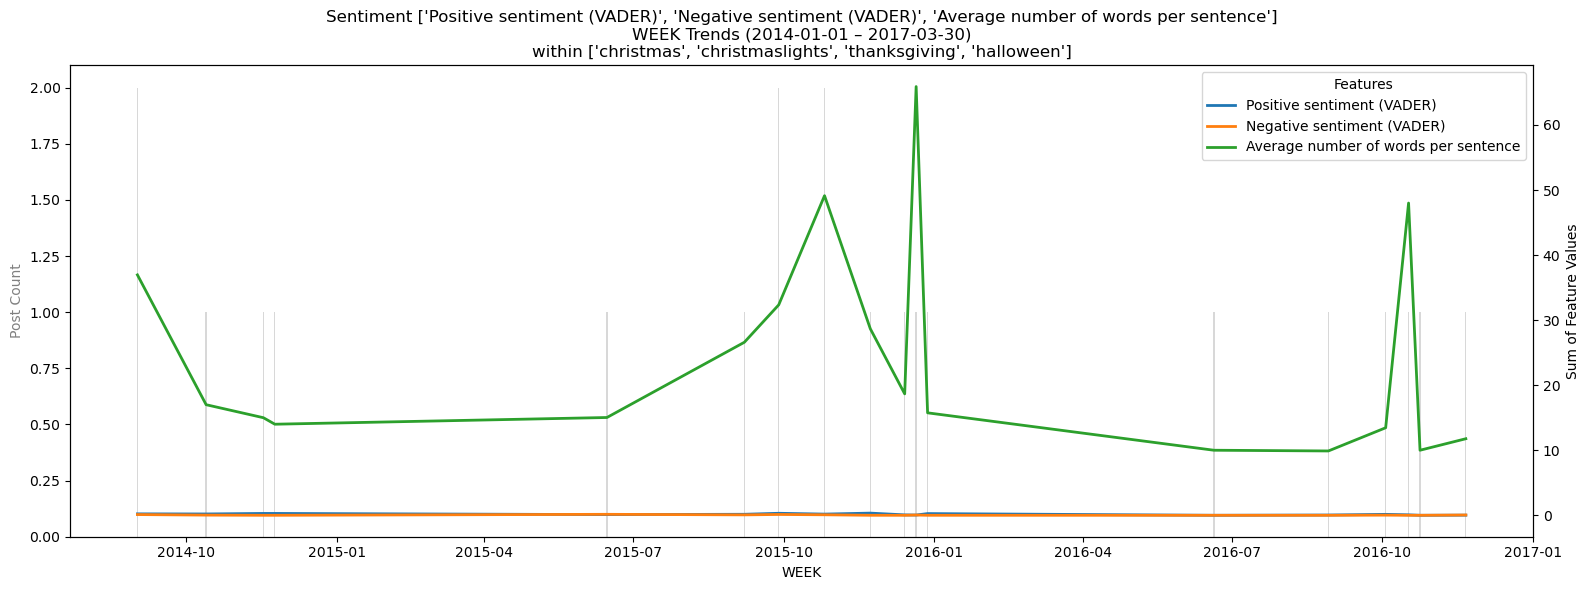


Title


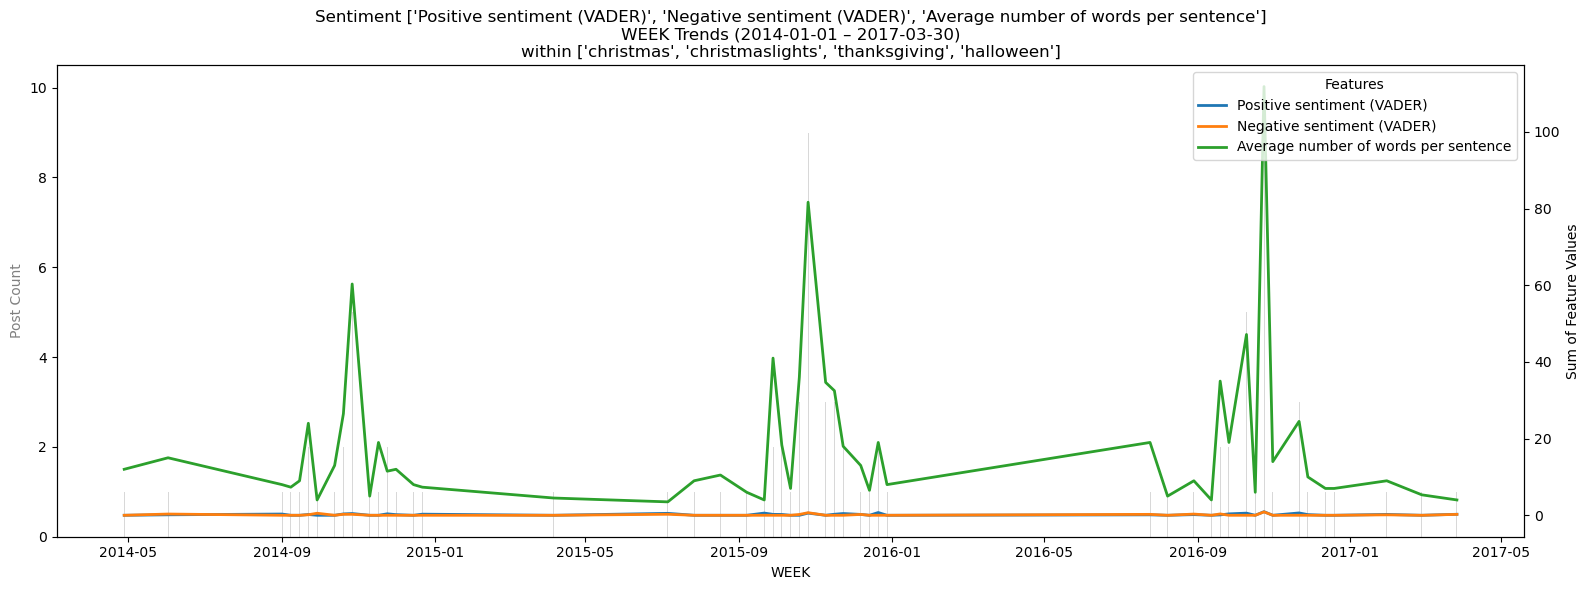

In [38]:
from week1_Yuri import plot_subreddits_features_trend
from week1_Yuri import features

# Process the PROPERTIES to extract individual features 
df_body_features = df_body["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])
features_body_df = pd.DataFrame(df_body_features.tolist(), columns=features, index=df_body.index)
df_body_prop = pd.concat([df_body.drop(columns=["PROPERTIES"]), features_body_df], axis=1)

df_title_features = df_title["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])
features_title_df = pd.DataFrame(df_title_features.tolist(), columns=features, index=df_title.index)
df_title_prop = pd.concat([df_title.drop(columns=["PROPERTIES"]), features_title_df], axis=1)

subreddits_list = HOLIDAYS[0:4]
start_time = "2014-01-01"
end_time = "2017-03-30"

# Select specific features to analyze 
features_list = [
    "Positive sentiment (VADER)", 
    "Negative sentiment (VADER)", 
    "Average number of words per sentence"
    ]

period = "W"  # D W M Y (resolution)

print("Body")
plot_subreddits_features_trend(df_body_prop, subreddits_list, start_time, end_time, features_list, period)

print("\nTitle")
plot_subreddits_features_trend(df_title_prop, subreddits_list, start_time, end_time, features_list, period)

### Analysis of Major Holidays


Christmas Subreddits - Seasonal Patterns


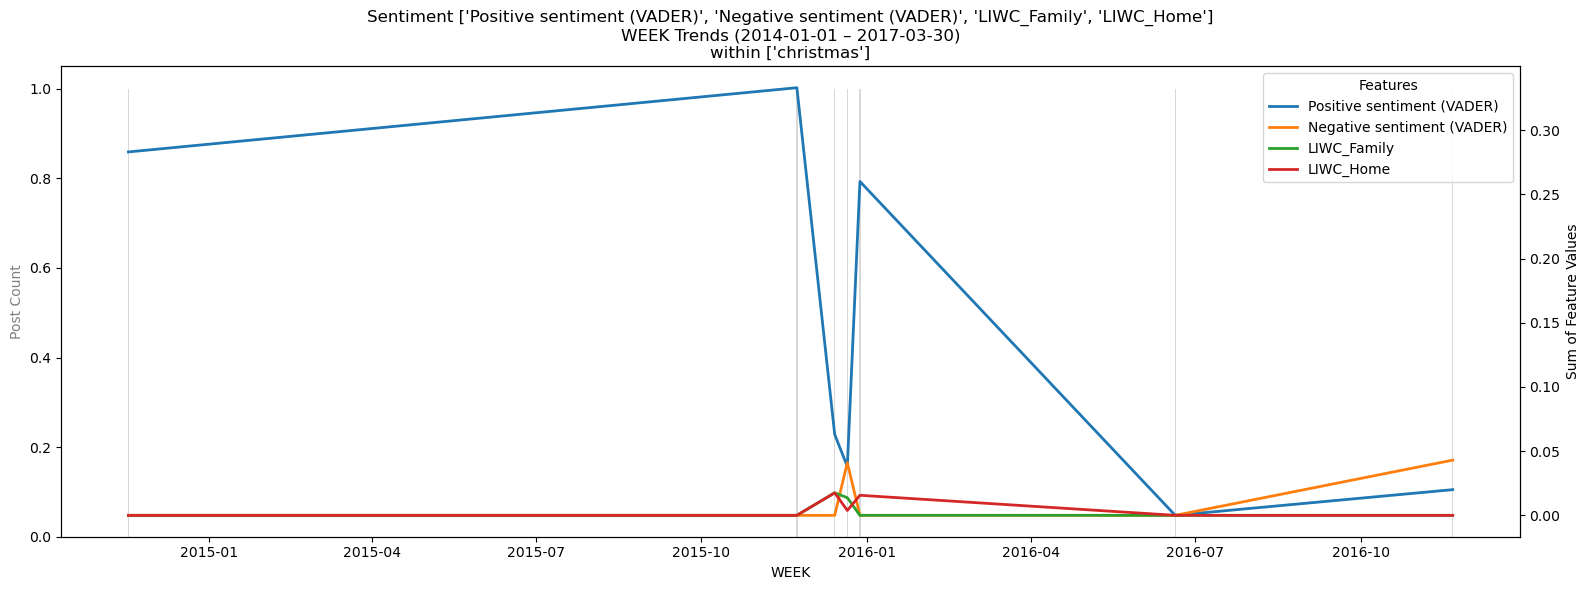


Halloween Subreddits - Seasonal Patterns


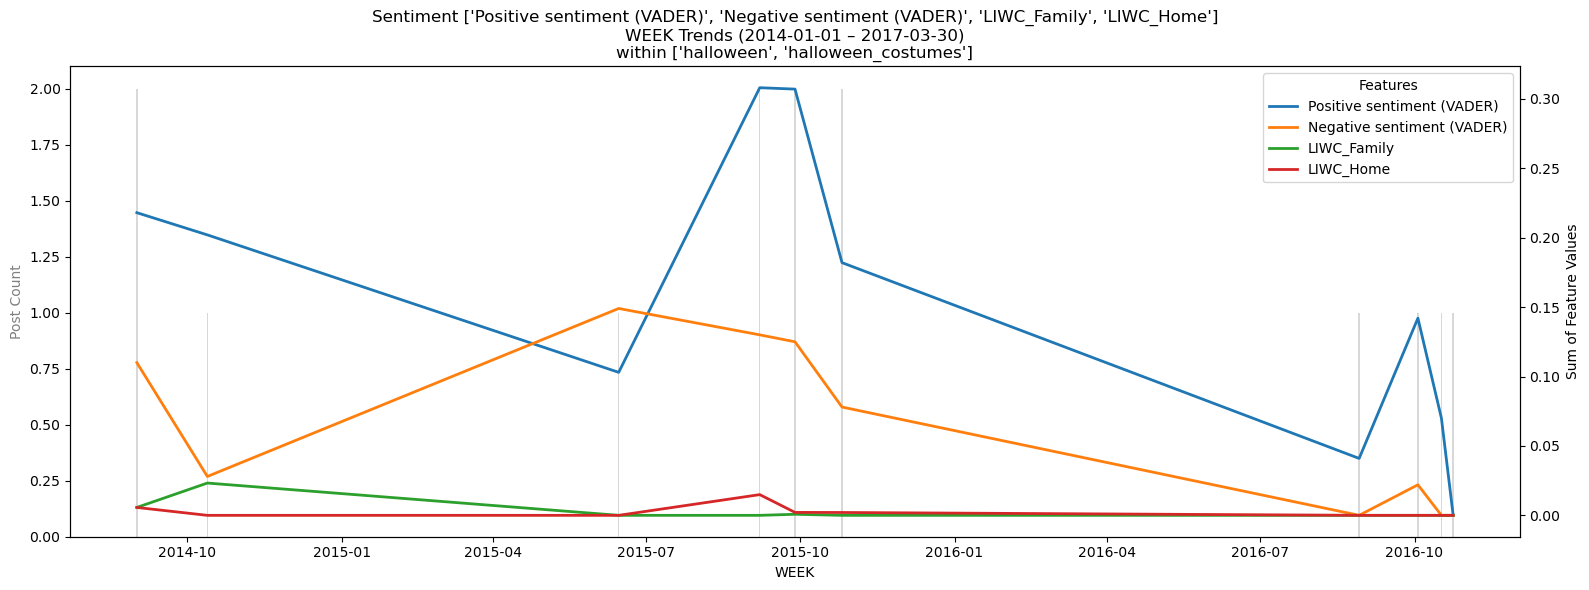

In [40]:
# Focus on Christmas
feature = [
    "Positive sentiment (VADER)", 
    "Negative sentiment (VADER)", 
    "LIWC_Family", 
    "LIWC_Home"
    ]

# Focus on Christmas
christmas_subs = ['christmas']
print("Christmas Subreddits - Seasonal Patterns")
plot_subreddits_features_trend(df_body_prop, christmas_subs, start_time, end_time, feature, period)

# Focus on Halloween
halloween_subs = ['halloween', 'halloween_costumes']
print("\nHalloween Subreddits - Seasonal Patterns")
plot_subreddits_features_trend(df_body_prop, halloween_subs, start_time, end_time, feature, period)
